# SONAR PARTIE 1
# Etape 1 : définir le problème à résoudre
# Classifier les objets détectés par sonar: Mines (M) ou Roches (R) basé sur les signaux acoustiques

# 2 - Acquérir les données

In [1]:
import os
import pandas as pd

# Charger le dataset sonar
sonar_data = pd.read_csv("data/sonar_all-data.csv", header=None)
print("Dimensions du dataset:", sonar_data.shape)
print("\nPremières lignes:")
print(sonar_data.head())

Dimensions du dataset: (208, 61)

Premières lignes:
       0       1       2       3       4       5       6       7       8   \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   

       9   ...      51      52      53      54      55      56      57  \
0  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084   
1  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
2  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
3  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.0044   
4  0.4459  ...  0.0031  0.0054  0.0105  0.0110  0.0015  0.0072  0.0048   

       58      59  60  
0  0.0090  0.003

# 3 - Préparation et nettoyage des données

In [2]:
import numpy as np

# Afficher les informations sur le dataset
print("Informations sur le dataset:")
print(sonar_data.info())

# Vérifier les valeurs manquantes
print("\nValeurs manquantes par colonne:")
print(sonar_data.isnull().sum())

# Statistiques descriptives
print("\nStatistiques descriptives:")
print(sonar_data.describe())

# La dernière colonne est la classe (M ou R)
# Renommer les colonnes pour plus de clarté
columns = [f'feature_{i}' for i in range(60)] + ['class']
sonar_data.columns = columns

print("\nNoms des colonnes après renommage:")
print(sonar_data.columns.tolist())

# Encoder la classe: M=1 (Mine), R=0 (Rock)
sonar_data['class'] = sonar_data['class'].map({'M': 1, 'R': 0})

print("\nDistribution des classes:")
print(sonar_data['class'].value_counts())

Informations sur le dataset:
<class 'pandas.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       208 non-null    float64
 1   1       208 non-null    float64
 2   2       208 non-null    float64
 3   3       208 non-null    float64
 4   4       208 non-null    float64
 5   5       208 non-null    float64
 6   6       208 non-null    float64
 7   7       208 non-null    float64
 8   8       208 non-null    float64
 9   9       208 non-null    float64
 10  10      208 non-null    float64
 11  11      208 non-null    float64
 12  12      208 non-null    float64
 13  13      208 non-null    float64
 14  14      208 non-null    float64
 15  15      208 non-null    float64
 16  16      208 non-null    float64
 17  17      208 non-null    float64
 18  18      208 non-null    float64
 19  19      208 non-null    float64
 20  20      208 non-null    float64
 21  21      208 non-null 

# 4 - Analyse et exploration des données

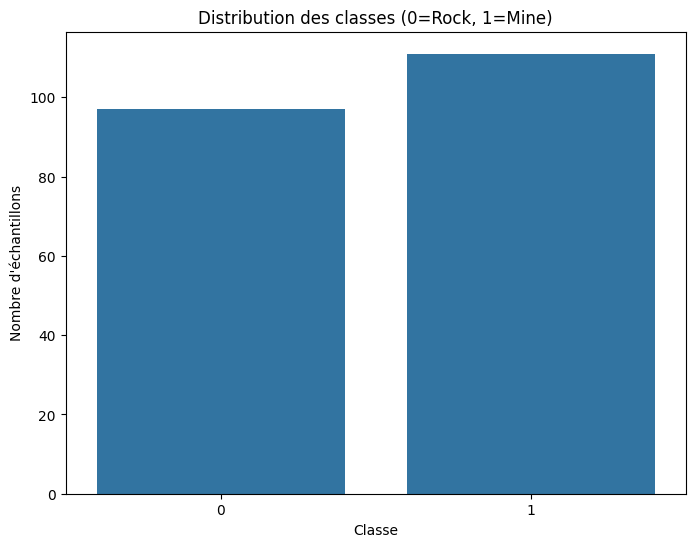

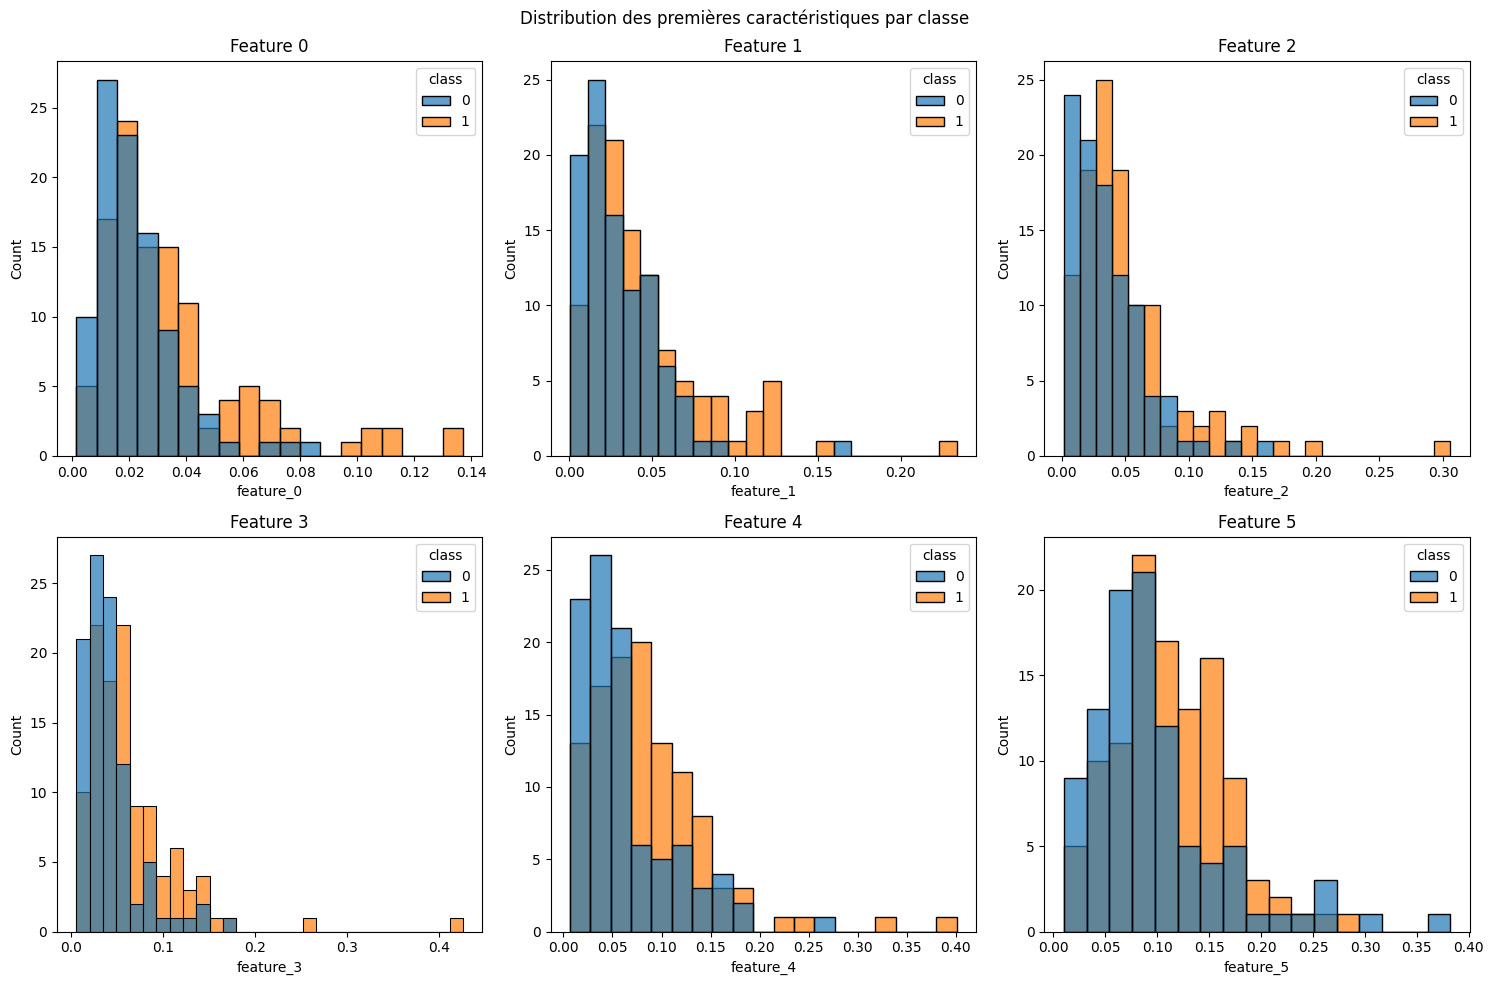

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisation de la distribution des classes
plt.figure(figsize=(8, 6))
sns.countplot(x='class', data=sonar_data)
plt.title('Distribution des classes (0=Rock, 1=Mine)')
plt.xlabel('Classe')
plt.ylabel('Nombre d\'échantillons')
plt.show()

# Visualisation des distributions des premières caractéristiques
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution des premières caractéristiques par classe')

for i in range(6):
    row = i // 3
    col = i % 3
    sns.histplot(data=sonar_data, x=f'feature_{i}', hue='class', ax=axes[row, col], alpha=0.7)
    axes[row, col].set_title(f'Feature {i}')

plt.tight_layout()
plt.show()

# Analyse de corrélation

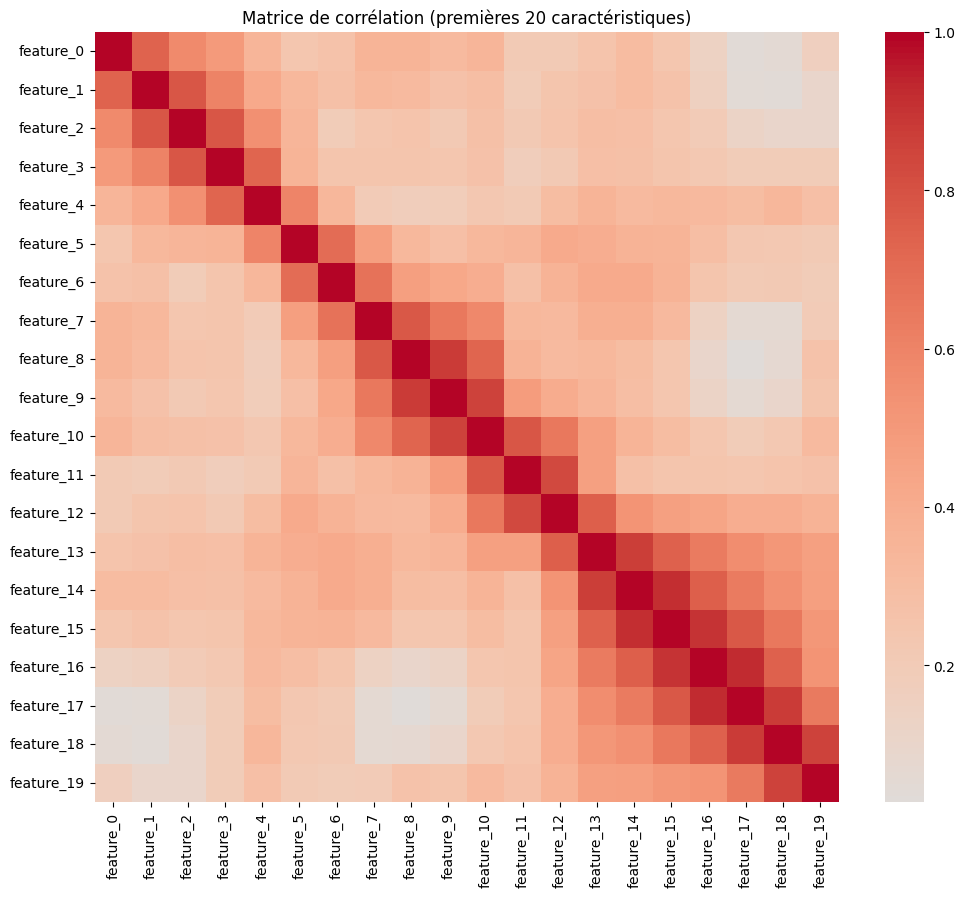

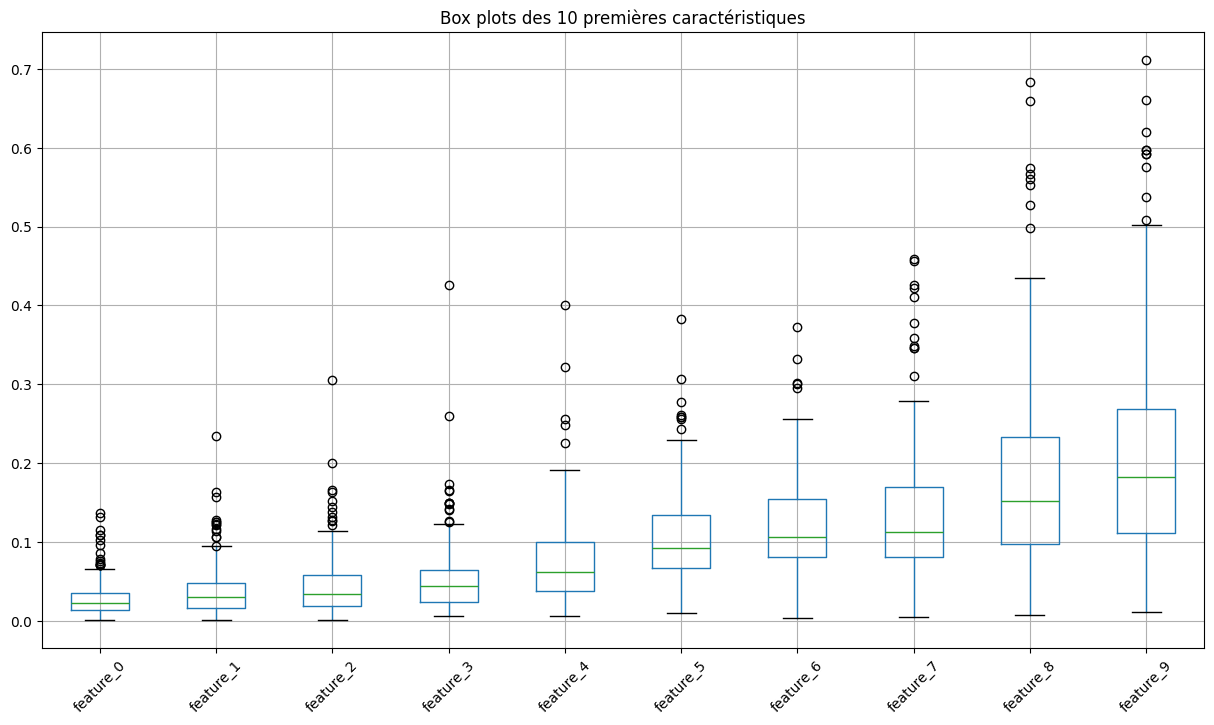


Statistiques par classe:
       feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
class                                                                     
0       0.022498   0.030303   0.035951   0.041447   0.062028   0.096224   
1       0.034989   0.045544   0.050720   0.064768   0.086715   0.111864   

       feature_6  feature_7  feature_8  feature_9  ...  feature_50  \
class                                              ...               
0       0.114180   0.117596   0.137392   0.159325  ...    0.012311   
1       0.128359   0.149832   0.213492   0.251022  ...    0.019352   

       feature_51  feature_52  feature_53  feature_54  feature_55  feature_56  \
class                                                                           
0        0.010453    0.009640    0.009518    0.008567    0.007430    0.007814   
1        0.016014    0.011643    0.012185    0.009923    0.008914    0.007825   

       feature_57  feature_58  feature_59  
class                  

In [4]:
# Calcul de la matrice de corrélation pour les premières caractéristiques
correlation_matrix = sonar_data.iloc[:, :20].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation (premières 20 caractéristiques)')
plt.show()

# Box plots pour détecter les outliers
plt.figure(figsize=(15, 8))
sonar_data.iloc[:, :10].boxplot()
plt.title('Box plots des 10 premières caractéristiques')
plt.xticks(rotation=45)
plt.show()

# Statistiques par classe
print("\nStatistiques par classe:")
print(sonar_data.groupby('class').mean().head())

# 5 - Préparation des données pour le Machine Learning

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Séparation des caractéristiques (X) et de la cible (y)
X = sonar_data.iloc[:, :-1].values  # Toutes les colonnes sauf la dernière
y = sonar_data['class'].values      # La dernière colonne (classe)

print("Dimensions de X:", X.shape)
print("Dimensions de y:", y.shape)

# Normalisation des caractéristiques
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nExemple des données normalisées:")
print("Moyenne:", X_scaled.mean(axis=0)[:5])  # Afficher les moyennes des 5 premières features
print("Écart-type:", X_scaled.std(axis=0)[:5])  # Afficher les écarts-types des 5 premières features

# Division en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTaille de l'ensemble d'entraînement: {X_train.shape[0]} échantillons")
print(f"Taille de l'ensemble de test: {X_test.shape[0]} échantillons")
print(f"Répartition des classes dans l'entraînement: {np.bincount(y_train)}")
print(f"Répartition des classes dans le test: {np.bincount(y_test)}")

Dimensions de X: (208, 60)
Dimensions de y: (208,)

Exemple des données normalisées:
Moyenne: [ 1.70803542e-17  6.83214169e-17 -1.19562480e-16  1.62263365e-16
 -1.79343719e-16]
Écart-type: [1. 1. 1. 1. 1.]

Taille de l'ensemble d'entraînement: 166 échantillons
Taille de l'ensemble de test: 42 échantillons
Répartition des classes dans l'entraînement: [77 89]
Répartition des classes dans le test: [20 22]
